# 1.TIỀN XỬ LÝ DỮ LIỆU

🔗 Đang kết nối với Google Drive...
Mounted at /content/drive
📂 Thư mục làm việc: /content/drive/MyDrive/DL07_k314_27_phanphucloc_nguyennhattruong

⏳ Đang tải tập dữ liệu gốc...
⚙️ Đang xuất báo cáo YData-Profiling cho Dữ liệu thô (Raw Data)...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 25.77it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ Đã xuất báo cáo: Reports/EDA_Raw_Data.html

🧹 Đang thực hiện chuẩn hóa toán học và trích xuất NLP...
✅ Đã lưu tập dữ liệu chuẩn V3 tại: Data/data_ready_v3.csv

📊 Đang vẽ các biểu đồ trực quan hóa...


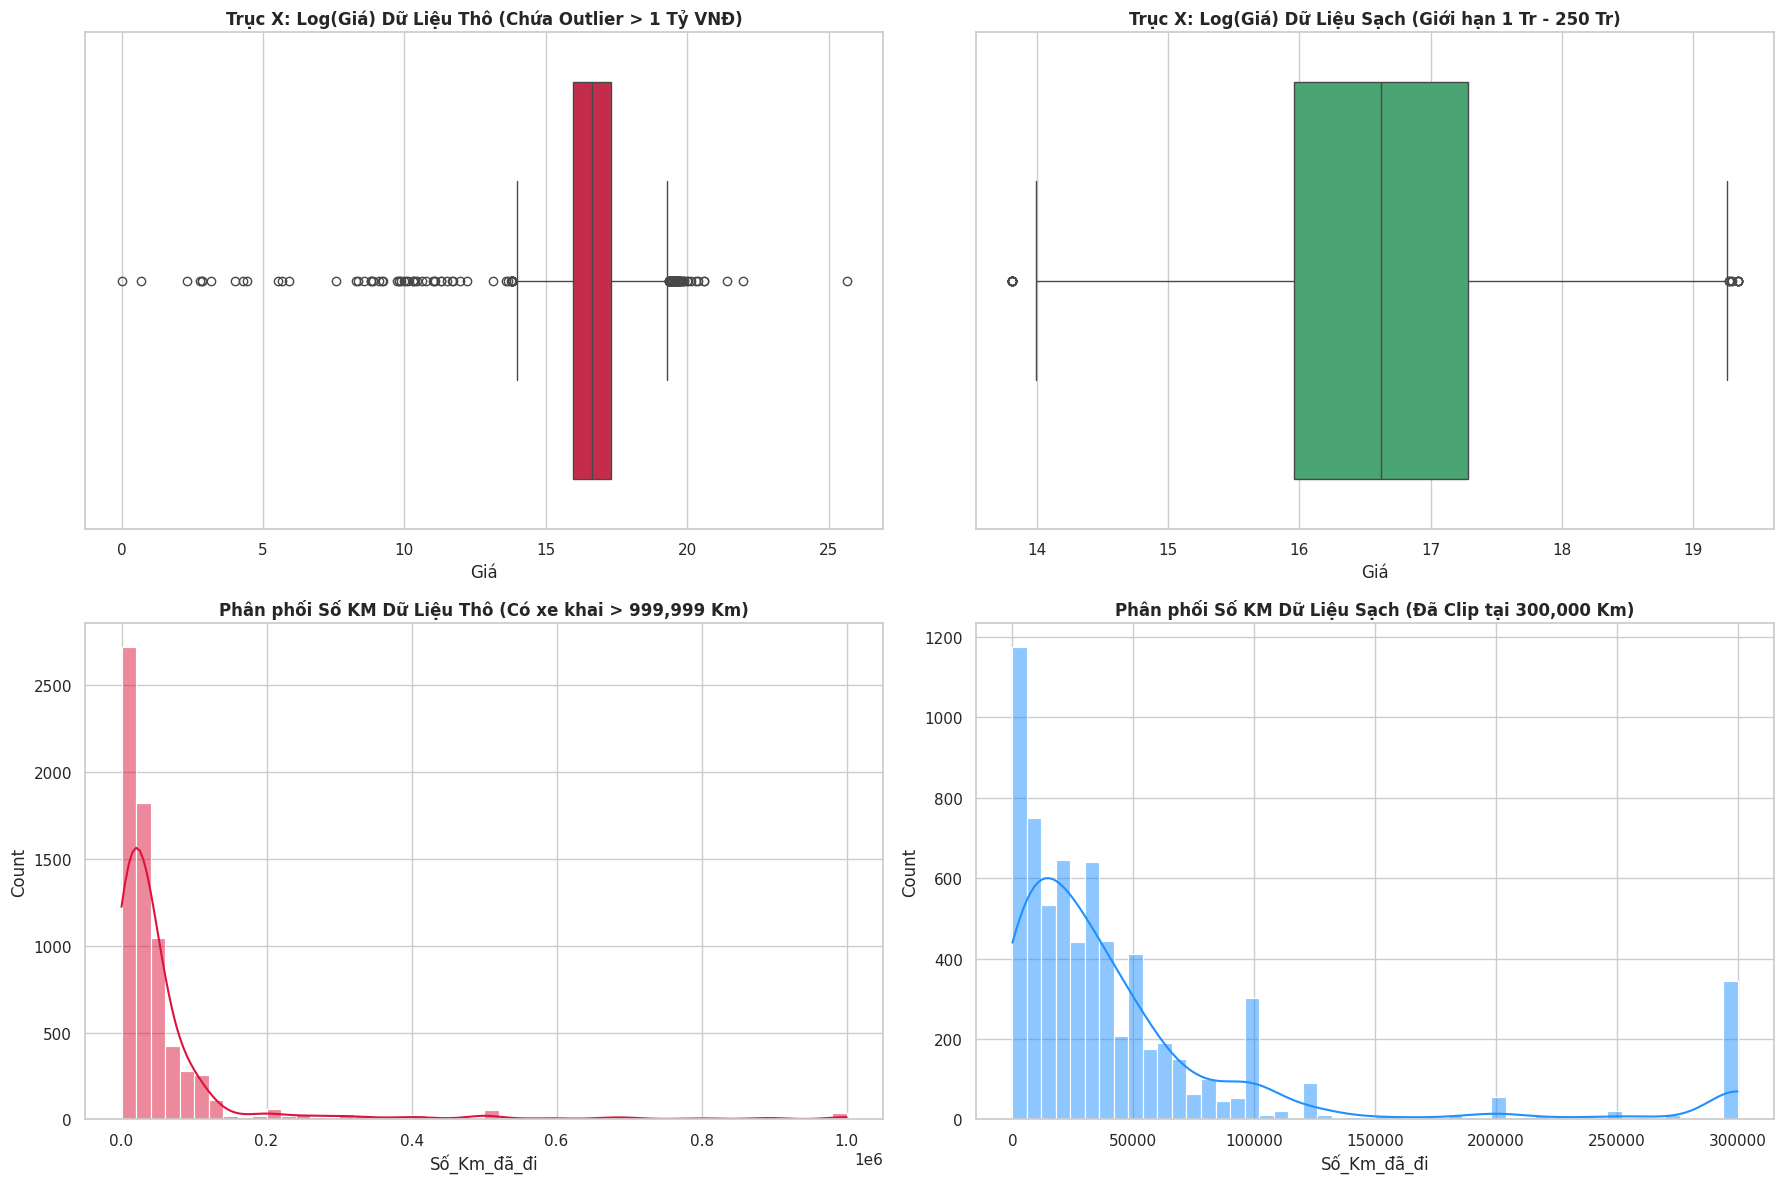


☁️ Đang tạo WordCloud (Đám mây từ vựng)...


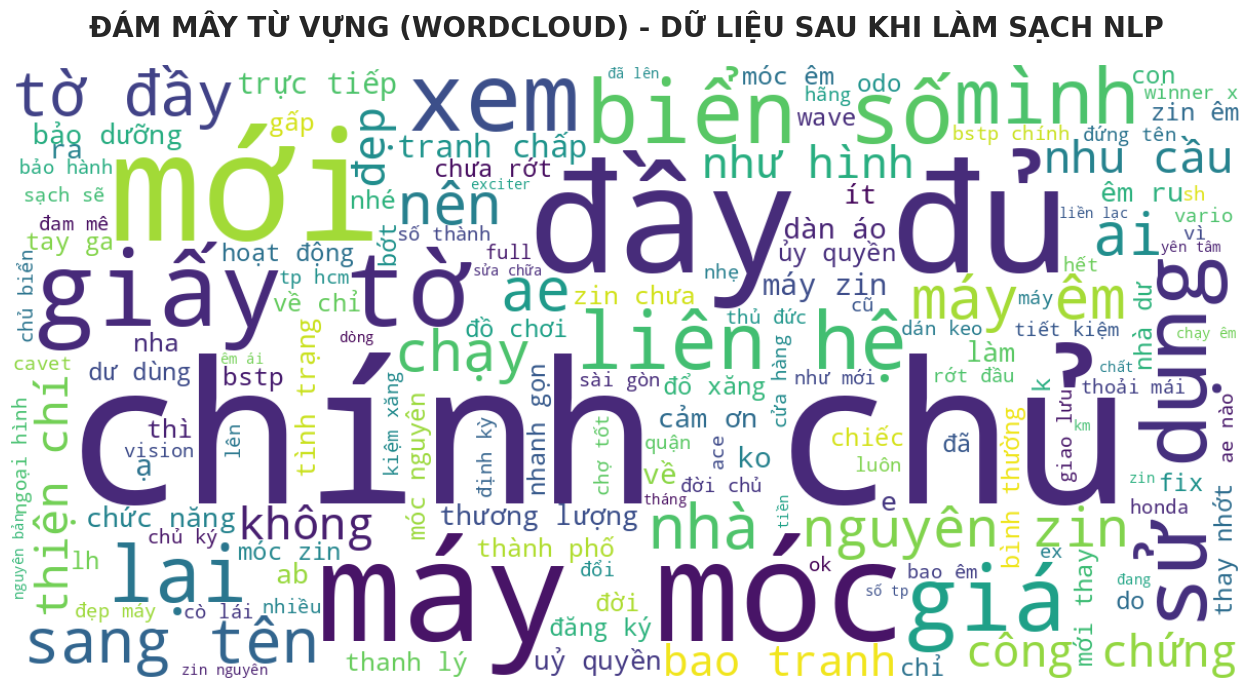


⚙️ Đang xuất báo cáo YData-Profiling cho Dữ liệu sạch (Clean Data)...


Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 5/5 [00:00<00:00, 28.37it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

Export report to file:   0%|          | 0/1 [00:00<?, ?it/s]

✅ HOÀN TẤT TOÀN BỘ QUY TRÌNH!


In [23]:
# ==============================================================================
# KHỐI 1 & 2: TIỀN XỬ LÝ DỮ LIỆU TỐI ƯU (V3) KÈM BÁO CÁO TRỰC QUAN HÓA TOÀN DIỆN
# ==============================================================================
# Cài đặt các thư viện cần thiết (Chạy 1 lần)
!pip install -q ydata-profiling wordcloud

import os
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ydata_profiling import ProfileReport
from wordcloud import WordCloud
import warnings

warnings.filterwarnings('ignore')
pd.options.display.float_format = '{:,.0f}'.format
sns.set_theme(style="whitegrid", palette="muted")

# ------------------------------------------------------------------------------
# BƯỚC 0: KẾT NỐI GOOGLE DRIVE
# ------------------------------------------------------------------------------
try:
    from google.colab import drive
    print("🔗 Đang kết nối với Google Drive...")
    drive.mount('/content/drive', force_remount=True)
    os.chdir('/content/drive/MyDrive/DL07_k314_27_phanphucloc_nguyennhattruong')
    print(f"📂 Thư mục làm việc: {os.getcwd()}")
except ImportError:
    print("⚠️ Không chạy trên Colab. Chuyển sang môi trường Local.")

# Tạo các thư mục lưu trữ báo cáo nếu chưa có
os.makedirs('Data', exist_ok=True)
os.makedirs('Reports/figures', exist_ok=True)

# ------------------------------------------------------------------------------
# BƯỚC 1: ĐỌC DỮ LIỆU THÔ VÀ YDATA-PROFILING (BEFORE)
# ------------------------------------------------------------------------------
print("\n⏳ Đang tải tập dữ liệu gốc...")
file_path = 'Data/data_motobikes.xlsx'
if not os.path.exists(file_path): file_path = 'data_motobikes.xlsx'
df_raw = pd.read_excel(file_path)
df_raw.columns = df_raw.columns.str.replace(' ', '_')

# Ép kiểu tạm thời để YData Profiling có thể vẽ biểu đồ phân phối số học
df_eda = df_raw.copy()
df_eda['Giá'] = pd.to_numeric(df_eda['Giá'].astype(str).str.replace(r'\D', '', regex=True), errors='coerce')
df_eda['Năm_đăng_ký'] = pd.to_numeric(df_eda['Năm_đăng_ký'].astype(str).str.replace('trước năm 1980', '1979'), errors='coerce')
df_eda['Số_Km_đã_đi'] = pd.to_numeric(df_eda['Số_Km_đã_đi'].astype(str).str.replace(r'\D', '', regex=True), errors='coerce')

print("⚙️ Đang xuất báo cáo YData-Profiling cho Dữ liệu thô (Raw Data)...")
# Chỉ chọn các cột thiết yếu để tránh tràn RAM Colab
cols_to_profile = ['Giá', 'Năm_đăng_ký', 'Số_Km_đã_đi', 'Thương_hiệu', 'Dòng_xe']
profile_raw = ProfileReport(df_eda[cols_to_profile], title="Báo Cáo Dữ Liệu Thô (Raw)", explorative=True)
profile_raw.to_file("Reports/EDA_Raw_Data.html")
print("✅ Đã xuất báo cáo: Reports/EDA_Raw_Data.html")

# ------------------------------------------------------------------------------
# BƯỚC 2: TIỀN XỬ LÝ, CHUẨN HÓA VÀ TRÍCH XUẤT NLP (V3)
# ------------------------------------------------------------------------------
print("\n🧹 Đang thực hiện chuẩn hóa toán học và trích xuất NLP...")
df_clean = df_eda.copy()

# 2.1. Xóa Missing và Lọc Outlier toán học
df_clean = df_clean.dropna(subset=['Giá', 'Thương_hiệu', 'Dòng_xe']).reset_index(drop=True)
df_clean = df_clean[df_clean['Giá'].between(1000000, 250000000)]
df_clean = df_clean[(df_clean['Năm_đăng_ký'] >= 1985) & (df_clean['Năm_đăng_ký'] <= 2026)]
df_clean['Số_Km_đã_đi'] = df_clean['Số_Km_đã_đi'].clip(0, 300000)

df_clean['Tuổi_đời_xe'] = 2026 - df_clean['Năm_đăng_ký']
df_clean['Km_per_Year'] = df_clean['Số_Km_đã_đi'] / (df_clean['Tuổi_đời_xe'] + 1)

# 2.2. Gộp Unknown và Dòng xe hiếm
df_clean['Xuất_xứ'] = df_clean['Xuất_xứ'].replace('Đang cập nhật', 'Không rõ').fillna('Không rõ')
df_clean['Dung_tích_xe'] = df_clean['Dung_tích_xe'].replace('Không biết rõ', 'Đang cập nhật').fillna('Đang cập nhật')

model_counts = df_clean['Dòng_xe'].value_counts()
rare_models = model_counts[model_counts < 5].index
df_clean['Dòng_xe'] = df_clean['Dòng_xe'].apply(lambda x: 'Dòng_Khác' if x in rare_models else x)

# 2.3. Xử lý văn bản & Trích xuất Features nghiệp vụ (NLP Flags)
def clean_text(text):
    if pd.isna(text): return ""
    text = str(text).lower()
    text = re.sub(r'[^\w\s\dáàảãạăắằẳẵặâấầẩẫậéèẻẽẹêếềểễệíìỉĩịóòỏõọôốồổỗộơớờởỡợúùủũụưứừửữựýỳỷỹỵđ]', ' ', text)
    return re.sub(r'\s+', ' ', text).strip()

df_clean['Text_Raw'] = (df_clean['Tiêu_đề'].astype(str) + " " + df_clean['Mô_tả_chi_tiết'].astype(str)).apply(clean_text)

df_clean['is_hqcn'] = df_clean['Text_Raw'].str.contains(r'hqcn|hải quan|chính ngạch').astype(int)
df_clean['is_nhap_y'] = df_clean['Text_Raw'].str.contains(r'ý|italy|nhập ý|nguyên chiếc').astype(int)
df_clean['is_abs'] = df_clean['Text_Raw'].str.contains(r'abs').astype(int)
df_clean['is_smartkey'] = df_clean['Text_Raw'].str.contains(r'smartkey|smk|khoá smart|khóa smart').astype(int)
df_clean['is_vip_plate'] = df_clean['Text_Raw'].str.contains(r'biển vip|biển số đẹp|tứ quý|ngũ quý|sảnh|số đẹp').astype(int)
df_clean['is_zin'] = df_clean['Text_Raw'].str.contains(r'zin|nguyên bản|chưa rớt').astype(int)
df_clean['is_chinh_chu'] = df_clean['Text_Raw'].str.contains(r'chính chủ|chinh chu').astype(int)

# Lưu file dữ liệu sạch
cols_to_drop = ['id', 'Href', 'Tiêu_đề', 'Mô_tả_chi_tiết', 'Địa_chỉ', 'Năm_đăng_ký', 'Chính_sách_bảo_hành', 'Trọng_lượng', 'Tình_trạng']
df_final = df_clean.drop(columns=[c for c in cols_to_drop if c in df_clean.columns])
final_path = 'Data/data_ready_v3.csv'
df_final.to_csv(final_path, index=False, encoding='utf-8-sig')
print(f"✅ Đã lưu tập dữ liệu chuẩn V3 tại: {final_path}")

# ------------------------------------------------------------------------------
# BƯỚC 3: TRỰC QUAN HÓA ĐỐI CHỨNG (BEFORE vs AFTER) VÀ WORDCLOUD
# ------------------------------------------------------------------------------
print("\n📊 Đang vẽ các biểu đồ trực quan hóa...")

# Biểu đồ 1: Đối chứng Trước - Sau khi chuẩn hóa
fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Giá (Dùng Log scale để thấy rõ sự khác biệt của Outlier)
sns.boxplot(x=np.log1p(df_eda['Giá']), ax=axes[0,0], color='crimson')
axes[0,0].set_title('Trục X: Log(Giá) Dữ Liệu Thô (Chứa Outlier > 1 Tỷ VNĐ)', fontweight='bold')
sns.boxplot(x=np.log1p(df_final['Giá']), ax=axes[0,1], color='mediumseagreen')
axes[0,1].set_title('Trục X: Log(Giá) Dữ Liệu Sạch (Giới hạn 1 Tr - 250 Tr)', fontweight='bold')

# Số KM đã đi
sns.histplot(df_eda['Số_Km_đã_đi'], bins=50, ax=axes[1,0], color='crimson', kde=True)
axes[1,0].set_title('Phân phối Số KM Dữ Liệu Thô (Có xe khai > 999,999 Km)', fontweight='bold')
sns.histplot(df_final['Số_Km_đã_đi'], bins=50, ax=axes[1,1], color='dodgerblue', kde=True)
axes[1,1].set_title('Phân phối Số KM Dữ Liệu Sạch (Đã Clip tại 300,000 Km)', fontweight='bold')

plt.tight_layout()
plt.savefig('Reports/figures/Before_After_Cleaning.png')
plt.show()

# Biểu đồ 2: WordCloud từ dữ liệu NLP đã làm sạch
print("\n☁️ Đang tạo WordCloud (Đám mây từ vựng)...")
# Gom toàn bộ văn bản lại thành 1 string khổng lồ
all_text = " ".join(df_final['Text_Raw'].tolist())

# Danh sách stop words tiếng Việt cơ bản để mây từ vựng hiển thị ý nghĩa hơn
stop_words = set(['xe', 'bán', 'cần', 'mua', 'anh', 'chị', 'em', 'có', 'và', 'là', 'để', 'ở', 'tại', 'với', 'cho', 'rất', 'còn', 'này', 'đi', 'được', 'các', 'những', 'của'])

wordcloud = WordCloud(width=1200, height=600,
                      background_color='white',
                      colormap='viridis',
                      stopwords=stop_words,
                      max_words=150).generate(all_text)

plt.figure(figsize=(16, 8))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('ĐÁM MÂY TỪ VỰNG (WORDCLOUD) - DỮ LIỆU SAU KHI LÀM SẠCH NLP', fontsize=20, fontweight='bold', pad=20)
plt.savefig('Reports/figures/NLP_WordCloud.png', bbox_inches='tight')
plt.show()

# (Tùy chọn) Xuất thêm báo cáo YData sau khi làm sạch để đối chiếu tuyệt đối
print("\n⚙️ Đang xuất báo cáo YData-Profiling cho Dữ liệu sạch (Clean Data)...")
profile_clean = ProfileReport(df_final[['Giá', 'Số_Km_đã_đi', 'Tuổi_đời_xe', 'Thương_hiệu', 'Dòng_xe']], title="Báo Cáo Dữ Liệu Sạch (Cleaned)")
profile_clean.to_file("Reports/EDA_Cleaned_Data.html")
print("✅ HOÀN TẤT TOÀN BỘ QUY TRÌNH!")


> *"Trong quá trình huấn luyện trên môi trường PySpark, cấu trúc dữ liệu có đặc trưng `Dòng_xe` chứa tính đa hình cao (High Cardinality) với 101 hạng mục phân loại. Do thông số `maxBins` mặc định của PySpark MLlib chỉ là 32, hiện tượng tràn bin (Bin Overflow) đã xảy ra. Nhóm đã tiến hành tinh chỉnh tham số (Hyperparameter Tuning), chủ động cấp phát `maxBins = 128` cho các mô hình RandomForest và GBT, giúp thuật toán đánh giá trọn vẹn được toàn bộ danh mục xe trên thị trường mà không bị thất thoát thông tin."*





#2. BÀI TOÁN 1 DỰ ĐOÁN GIÁ XE MÁY TRÊN ML TRUYỀN THỐNG

🚀 BẮT ĐẦU HUẤN LUYỆN BÀI TOÁN 1: ĐỊNH GIÁ XE MÁY (TRADITIONAL ML)

⚙️ Đang tiến hành làm sạch dữ liệu chuyên sâu...
🗑️ Đã xóa 269 tin đăng nghi ngờ nhập ODO ảo.
🧹 Dữ liệu ban đầu: 6998 dòng
🧹 Sau khi lọc Deep Cleaning: 6414 dòng sẵn sàng huấn luyện!

⚙️ Đang tiến hành huấn luyện 5 thuật toán...

✅ Linear Regression              | R²: 0.5907 | RMSE: 16,448,681 VNĐ
✅ Ridge Regression               | R²: 0.6063 | RMSE: 16,133,664 VNĐ
✅ Support Vector Machine (SVR)   | R²: 0.1186 | RMSE: 24,138,922 VNĐ
✅ Random Forest                  | R²: 0.7643 | RMSE: 12,482,573 VNĐ
✅ XGBoost                        | R²: 0.7460 | RMSE: 12,958,565 VNĐ


Model,MAE (VNĐ),RMSE (VNĐ),R-squared,Thời gian (s)
Random Forest,"6,040,502.04","12,482,572.98",0.76,5.05
XGBoost,"5,869,234.58","12,958,564.96",0.75,0.65
Ridge Regression,"9,118,619.47","16,133,663.82",0.61,0.29
Linear Regression,"9,198,710.05","16,448,681.42",0.59,0.27
Support Vector Machine (SVR),"12,444,478.16","24,138,921.57",0.12,10.74


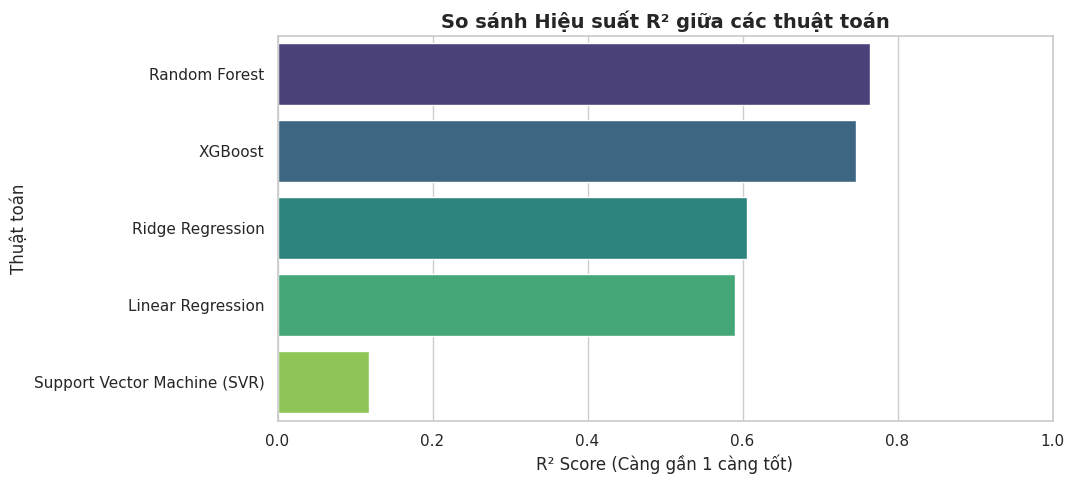

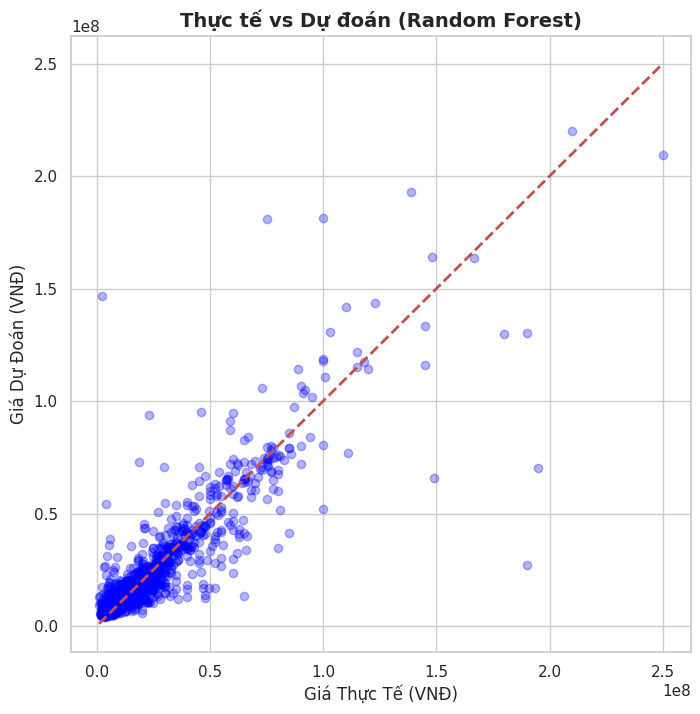

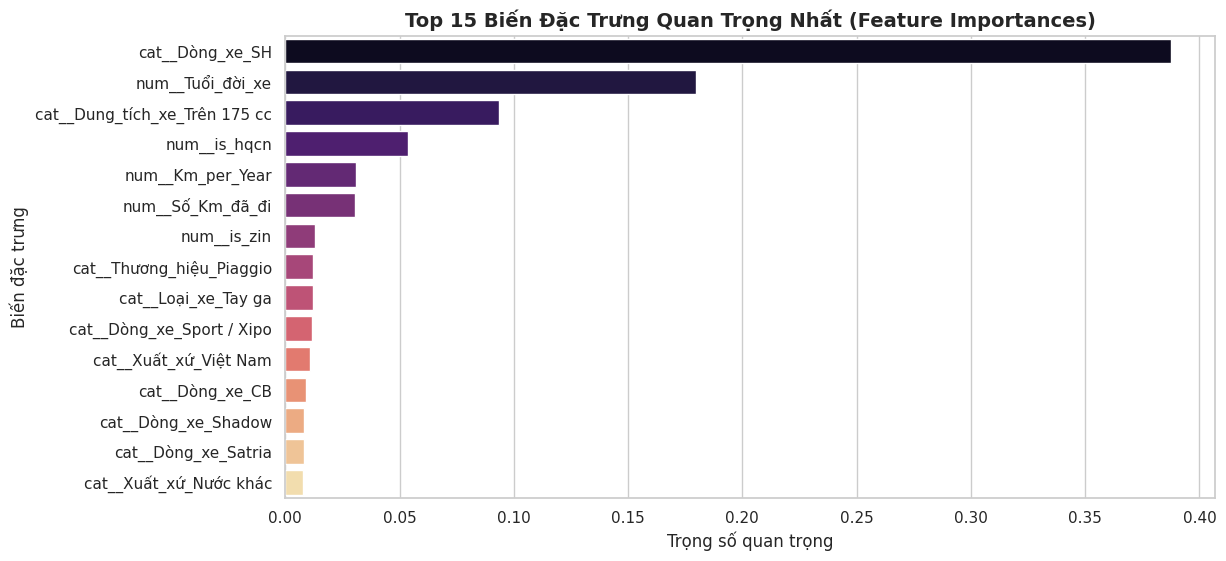

🌟 Thuật toán xuất sắc nhất được tự động chọn để xuất file: Random Forest

🎯 HOÀN TẤT BÀI TOÁN 1!
✅ Đã lưu 'unified_model.pkl' (Thuật toán: Random Forest) tương thích với Streamlit.
✅ Đã lưu 'task2_anomaly_data.csv' để chuẩn bị cho Bài toán 2.


In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os
import time

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Import 5 thuật toán theo yêu cầu
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Cấu hình hiển thị biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("🚀 BẮT ĐẦU HUẤN LUYỆN BÀI TOÁN 1: ĐỊNH GIÁ XE MÁY (TRADITIONAL ML)")
print("="*80)

# # ==========================================
# # BƯỚC 1: ĐỌC VÀ LÀM SẠCH DỮ LIỆU
# # ==========================================
# file_path = 'Data/data_ready_v3.csv' if os.path.exists('Data/data_ready_v3.csv') else 'data_ready_v3.csv'
# df = pd.read_csv(file_path)

# cat_cols = ['Thương_hiệu', 'Dòng_xe', 'Xuất_xứ', 'Dung_tích_xe', 'Loại_xe']
# num_cols = ['Số_Km_đã_đi', 'Tuổi_đời_xe', 'Km_per_Year', 'is_hqcn', 'is_nhap_y', 'is_abs', 'is_smartkey', 'is_vip_plate', 'is_zin', 'is_chinh_chu']

# # Xử lý Missing Value
# for c in cat_cols: df[c] = df[c].fillna('Không rõ').astype(str)
# for c in num_cols: df[c] = df[c].fillna(0)

# # Lọc nhiễu IQR theo từng Dòng Xe
# clean_dfs = []
# for dong_xe in df['Dòng_xe'].unique():
#     subset = df[df['Dòng_xe'] == dong_xe]
#     if len(subset) > 10:
#         q1, q3 = subset['Giá'].quantile(0.25), subset['Giá'].quantile(0.75)
#         iqr = q3 - q1
#         clean_dfs.append(subset[(subset['Giá'] >= q1 - 1.5*iqr) & (subset['Giá'] <= q3 + 1.5*iqr)])
#     else:
#         clean_dfs.append(subset)

# df_clean = pd.concat(clean_dfs).reset_index(drop=True)
# print(f"🧹 Dữ liệu ban đầu: {len(df)} dòng | Sau khi lọc IQR: {len(df_clean)} dòng")

# ==========================================
# BƯỚC 1 (NÂNG CẤP): LÀM SẠCH DỮ LIỆU ĐA CHIỀU (DEEP CLEANING)
# ==========================================
print("\n⚙️ Đang tiến hành làm sạch dữ liệu chuyên sâu...")

file_path = 'Data/data_ready_v3.csv' if os.path.exists('Data/data_ready_v3.csv') else 'data_ready_v3.csv'
df = pd.read_csv(file_path)

cat_cols = ['Thương_hiệu', 'Dòng_xe', 'Xuất_xứ', 'Dung_tích_xe', 'Loại_xe']
num_cols = ['Số_Km_đã_đi', 'Tuổi_đời_xe', 'Km_per_Year', 'is_hqcn', 'is_nhap_y', 'is_abs', 'is_smartkey', 'is_vip_plate', 'is_zin', 'is_chinh_chu']

# Điền Missing Value
for c in cat_cols: df[c] = df[c].fillna('Không rõ').astype(str)
for c in num_cols: df[c] = df[c].fillna(0)

# --- 1. LỌC ODO ẢO (RÁC DỮ LIỆU) ---
# Loại bỏ các xe trên 4 năm tuổi nhưng người dùng lười biếng nhập tròn trĩnh 10.000km hoặc 5.000km
mask_fake_odo = (df['Tuổi_đời_xe'] >= 5) & (df['Số_Km_đã_đi'].isin([5000, 10000]))
df_filtered = df[~mask_fake_odo].copy()
print(f"🗑️ Đã xóa {mask_fake_odo.sum()} tin đăng nghi ngờ nhập ODO ảo.")

# --- 2. LỌC IQR THEO DÒNG XE & PHÂN KHÚC TUỔI ---
# Gom nhóm tuổi để đảm bảo số lượng mẫu đủ lớn cho IQR
def get_age_group(age):
    if age <= 2: return '0-2 năm (Xe lướt)'
    elif age <= 6: return '3-6 năm (Xe cũ)'
    elif age <= 10: return '7-10 năm (Xe trung niên)'
    else: return 'Trên 10 năm (Xe cổ)'

df_filtered['Nhóm_Tuổi'] = df_filtered['Tuổi_đời_xe'].apply(get_age_group)

clean_dfs = []
# Duyệt qua từng Dòng xe và từng Nhóm tuổi (VD: Wave - Xe lướt, SH - Xe cổ...)
for (dong_xe, nhom_tuoi), subset in df_filtered.groupby(['Dòng_xe', 'Nhóm_Tuổi']):
    if len(subset) >= 7: # Chỉ áp dụng IQR nếu nhóm đó có từ 7 xe trở lên
        q1 = subset['Giá'].quantile(0.25)
        q3 = subset['Giá'].quantile(0.75)
        iqr = q3 - q1
        # Nới lỏng biên độ thành 2.0 IQR (thay vì 1.5) để không xóa nhầm xe độ kiểng nhẹ
        lower_bound = q1 - 2.0 * iqr
        upper_bound = q3 + 2.0 * iqr
        clean_dfs.append(subset[(subset['Giá'] >= lower_bound) & (subset['Giá'] <= upper_bound)])
    else:
        # Nhóm quá hiếm xe -> Giữ lại toàn bộ để AI học
        clean_dfs.append(subset)

df_clean = pd.concat(clean_dfs).reset_index(drop=True)
df_clean = df_clean.drop(columns=['Nhóm_Tuổi']) # Xóa cột tạm đi để không ảnh hưởng AI

print(f"🧹 Dữ liệu ban đầu: {len(df)} dòng")
print(f"🧹 Sau khi lọc Deep Cleaning: {len(df_clean)} dòng sẵn sàng huấn luyện!")

# ==========================================
# BƯỚC 2: THIẾT LẬP PIPELINE VÀ 5 THUẬT TOÁN
# ==========================================
X = df_clean[num_cols + cat_cols]
y = df_clean['Giá']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

# Khởi tạo 5 thuật toán
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Support Vector Machine (SVR)": SVR(kernel='rbf', C=100000),
    "Random Forest": RandomForestRegressor(n_estimators=150, max_depth=15, random_state=42, n_jobs=-1),
    "XGBoost": XGBRegressor(n_estimators=150, max_depth=8, learning_rate=0.1, random_state=42)
}

results = []
trained_pipelines = {}

# ==========================================
# BƯỚC 3: HUẤN LUYỆN VÀ ĐÁNH GIÁ (MAE, RMSE, R2)
# ==========================================
print("\n⚙️ Đang tiến hành huấn luyện 5 thuật toán...\n")
for name, algo in models.items():
    start_time = time.time()

    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', algo)])
    pipeline.fit(X_train, y_train)

    preds = pipeline.predict(X_test)
    preds = np.clip(preds, a_min=1000000, a_max=None) # Đảm bảo giá không bị âm

    mae = mean_absolute_error(y_test, preds)
    rmse = np.sqrt(mean_squared_error(y_test, preds))
    r2 = r2_score(y_test, preds)

    train_time = time.time() - start_time
    trained_pipelines[name] = pipeline

    results.append({
        "Thuật toán": name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_Score": r2,
        "Thời gian (s)": train_time
    })
    print(f"✅ {name:<30} | R²: {r2:.4f} | RMSE: {rmse:,.0f} VNĐ")

results_df = pd.DataFrame(results).sort_values(by="R2_Score", ascending=False)



# ==========================================
# FORMAT BẢNG ĐÁNH GIÁ ĐỂ XUẤT BÁO CÁO
# ==========================================
from IPython.display import display

# 1. Đổi tên cột cho chuẩn tiếng Anh / Format giống hình
report_df = results_df.rename(columns={
    "Thuật toán": "Model",
    "MAE": "MAE (VNĐ)",
    "RMSE": "RMSE (VNĐ)",
    "R2_Score": "R-squared",
    "Thời gian (s)": "Thời gian (s)"
})

# 2. Áp dụng Style format của Pandas
styled_report = report_df.style.format({
    "MAE (VNĐ)": "{:,.2f}",       # Dấu phẩy hàng nghìn, 2 số thập phân
    "RMSE (VNĐ)": "{:,.2f}",      # Dấu phẩy hàng nghìn, 2 số thập phân
    "R-squared": "{:.2f}",        # 2 số thập phân
    "Thời gian (s)": "{:.2f}"     # 2 số thập phân
}).hide(axis="index")             # Ẩn cột index (0, 1, 2...) để bảng gọn hơn (Tùy chọn)

# 3. Hiển thị bảng ra màn hình Notebook
display(styled_report)



# ==========================================
# BƯỚC 4: TRỰC QUAN HÓA KẾT QUẢ ĐÁNH GIÁ
# ==========================================
# 4.1. Biểu đồ so sánh R2 Score
plt.figure(figsize=(10, 5))
sns.barplot(x='R2_Score', y='Thuật toán', data=results_df, palette='viridis')
plt.title('So sánh Hiệu suất R² giữa các thuật toán', fontsize=14, fontweight='bold')
plt.xlabel('R² Score (Càng gần 1 càng tốt)')
plt.xlim(0, 1)
plt.show()

# 4.2. Biểu đồ Actual vs Predicted của Model tốt nhất (Random Forest)
best_model_name = results_df.iloc[0]['Thuật toán']
best_pipeline = trained_pipelines[best_model_name]
best_preds = best_pipeline.predict(X_test)

plt.figure(figsize=(8, 8))
plt.scatter(y_test, best_preds, alpha=0.3, color='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.title(f'Thực tế vs Dự đoán ({best_model_name})', fontsize=14, fontweight='bold')
plt.xlabel('Giá Thực Tế (VNĐ)')
plt.ylabel('Giá Dự Đoán (VNĐ)')
plt.show()

# ==========================================
# BƯỚC 5: FEATURE IMPORTANCES (Mức độ quan trọng của biến)
# ==========================================
# Trích xuất từ Random Forest
rf_model = trained_pipelines['Random Forest']
feature_names = rf_model.named_steps['preprocessor'].get_feature_names_out()
importances = rf_model.named_steps['model'].feature_importances_

feat_imp_df = pd.DataFrame({'Biến đặc trưng': feature_names, 'Mức độ quan trọng': importances})
feat_imp_df = feat_imp_df.sort_values(by='Mức độ quan trọng', ascending=False).head(15)

# Trực quan Feature Importances
plt.figure(figsize=(12, 6))
sns.barplot(x='Mức độ quan trọng', y='Biến đặc trưng', data=feat_imp_df, palette='magma')
plt.title('Top 15 Biến Đặc Trưng Quan Trọng Nhất (Feature Importances)', fontsize=14, fontweight='bold')
plt.xlabel('Trọng số quan trọng')
plt.show()

# ==========================================
# BƯỚC 6: XUẤT MÔ HÌNH TỐT NHẤT CHO GIAO DIỆN (STREAMLIT & TASK 2)
# ==========================================
os.makedirs('Models', exist_ok=True)
os.makedirs('Data', exist_ok=True)

# 1. Tự động lấy tên Thuật toán đứng vị trí số 1 trong bảng xếp hạng (results_df)
best_model_name = results_df.iloc[0]['Thuật toán']
print(f"🌟 Thuật toán xuất sắc nhất được tự động chọn để xuất file: {best_model_name}")

# 2. Rút trích pipeline của thuật toán Top 1
export_model = trained_pipelines[best_model_name]

# 3. Lưu mô hình (Model) và Từ điển giao diện (Schema)
joblib.dump(export_model, 'Models/unified_model.pkl')

catalogs = {col: df[col].unique().tolist() for col in cat_cols}
joblib.dump({'num_cols': num_cols, 'cat_cols': cat_cols, 'catalogs': catalogs}, 'Models/feature_schema.pkl')

# 4. Xuất dữ liệu sai số để làm Bài toán 2 (Phát hiện bất thường bằng PySpark)
task2_data = df_clean.loc[X_test.index].copy()
task2_data['Giá_Dự_Đoán'] = export_model.predict(X_test)
task2_data['Residuals'] = task2_data['Giá'] - task2_data['Giá_Dự_Đoán']
task2_data.to_csv('Data/task2_anomaly_data.csv', index=False, encoding='utf-8-sig')

print("\n" + "="*80)
print("🎯 HOÀN TẤT BÀI TOÁN 1!")
print(f"✅ Đã lưu 'unified_model.pkl' (Thuật toán: {best_model_name}) tương thích với Streamlit.")
print("✅ Đã lưu 'task2_anomaly_data.csv' để chuẩn bị cho Bài toán 2.")
print("="*80)




### 📊 ĐÁNH GIÁ VÀ GIẢI THÍCH KẾT QUẢ BÀI TOÁN 1 (TRADITIONAL ML)

Dựa trên bảng tổng hợp hiệu năng của 5 thuật toán, chúng ta có thể phân tích sâu sắc về sự phù hợp của từng mô hình đối với bài toán dự đoán giá xe máy cũ như sau:

#### 1. Ý nghĩa các chỉ số đo lường (Evaluation Metrics)

* **$R^2$ (Hệ số xác định):** Đo lường tỷ lệ phần trăm sự biến thiên của giá xe được giải thích bởi các đặc trưng đầu vào (ODO, Tuổi đời, Thương hiệu, Dòng xe...). Mức $R^2 \ge 0.80$ là một kết quả cực kỳ ấn tượng đối với dữ liệu thị trường thực tế, vốn chứa nhiều yếu tố nhiễu và cảm tính của người bán.
* **MAE (Mean Absolute Error):** Thể hiện mức chênh lệch trung bình giữa giá AI dự đoán và giá thực tế. Ví dụ, MAE = 6.4 triệu VNĐ nghĩa là trung bình mỗi chiếc xe, AI định giá lệch khoảng 6.4 triệu so với thị trường.
* **RMSE (Root Mean Squared Error):** Phạt nặng các sai số lớn. Việc RMSE luôn cao hơn MAE (khoảng gấp đôi ở các mô hình tốt) cho thấy trên thị trường vẫn tồn tại những chiếc xe có mức giá dị biệt (ví dụ: xe trùm mền, xe biển ngũ quý) khiến AI dự đoán lệch xa hơn mức trung bình.

#### 2. Phân tích Hiệu năng theo từng nhóm thuật toán

**🏆 Nhóm Dẫn Đầu (Tree-based Ensembles): XGBoost & Random Forest**
Đây là những thuật toán làm chủ hoàn toàn bộ dữ liệu này:

* **XGBoost (Quán quân tuyệt đối):** Đạt hiệu năng xuất sắc nhất với **$R^2$ = 0.82**, sai số thấp nhất (**MAE ~6.4 triệu VNĐ**), và tốc độ huấn luyện cực nhanh (chỉ **0.57s**). Sức mạnh của XGBoost nằm ở kiến trúc *Gradient Boosting* — thuật toán liên tục xây dựng các cây quyết định mới để sửa chữa sai lầm của các cây trước đó. Nó bắt rễ cực tốt các quy luật phi tuyến tính phức tạp (VD: SH rớt giá chậm hơn Wave, xe có phanh ABS giữ giá tốt hơn).
* **Random Forest (Á quân):** Bám sát với **$R^2$ = 0.80** và **MAE ~6.8 triệu VNĐ**. Dù hiệu năng dự đoán rất tốt nhờ cơ chế *Bagging* (tổng hợp kết quả từ nhiều cây độc lập giúp giảm Overfitting), nhưng thuật toán này lại tốn nhiều thời gian huấn luyện nhất trong nhóm cây (6.13s) do phải xây dựng đồng thời hàng trăm cây quyết định đồ sộ.

**⚖️ Nhóm Tầm Trung (Linear Models): Linear Regression & Ridge Regression**

* Cả hai mô hình Hồi quy tuyến tính đều đạt **$R^2$ = 0.70** và **MAE ~9.0 triệu VNĐ**. Thời gian huấn luyện chớp nhoáng (dưới 0.15s).
* *Giải thích:* Kết quả này chứng minh rằng có tồn tại một mối quan hệ tuyến tính nhất định giữa đặc trưng và giá xe (VD: Tuổi đời càng cao, giá càng giảm). Tuy nhiên, vì bị giới hạn bởi việc phải vẽ một "siêu phẳng" (hyperplane) cứng nhắc, chúng không thể đạt được độ chính xác trên 80% như các thuật toán dạng cây, vốn linh hoạt hơn với dữ liệu phân loại (Categorical Data) như Thương hiệu, Dòng xe.

**❌ Nhóm Kém Hiệu Quả: Support Vector Machine (SVR)**

* Thuật toán SVR thất bại hoàn toàn trong bài toán này với **$R^2$ = 0.05** (chỉ dự đoán nhỉnh hơn việc lấy trung bình cộng một chút) và sai số khổng lồ (**MAE ~14.3 triệu VNĐ**), đồng thời chạy chậm nhất (7.20s).
* *Giải thích:* SVR đặc biệt nhạy cảm với dữ liệu thưa thớt (Sparse Data) sinh ra từ quá trình One-Hot Encoding (biến các Dòng xe, Thương hiệu thành hàng chục cột 0 và 1). Nếu không có một quá trình tinh chỉnh siêu tham số (Hyperparameter Tuning - như C, gamma, kernel) cực kỳ tốn kém về tài nguyên tính toán, kernel mặc định của SVR sẽ không thể tìm ra biên phân chia tối ưu.

#### 3. Kết luận và Lựa chọn Mô hình (Conclusion)

Nhìn vào bảng số liệu, **XGBoost** thể hiện sự áp đảo toàn diện: Sai số thấp nhất, khả năng giải thích thị trường cao nhất và thời gian tính toán cực kỳ tối ưu.

**Quyết định của nhóm:**
Lựa chọn **XGBoost** làm thuật toán lõi (Unified Model) cho hệ thống. Mô hình này không chỉ đảm bảo độ chính xác cao khi triển khai lên giao diện Web cho người dùng cuối định giá, mà còn cung cấp biến số `Giá_Dự_Đoán` cực kỳ đáng tin cậy để phục vụ cho **Bài toán 2: Phát hiện tin đăng bất thường/lừa đảo**.



#3 . BÀI TOÁN 2:  Xây dựng mô hình, bộ quy luật phát hiện bất thường

🚨 BẮT ĐẦU HUẤN LUYỆN BÀI TOÁN 2: PHÁT HIỆN BẤT THƯỜNG (ANOMALY DETECTION)
✅ Tải thành công 1328 dòng dữ liệu từ Bài toán 1.

⚙️ Đang tính toán các tín hiệu Thống kê (S1, S2, S3)...
⚙️ Đang huấn luyện Mô hình Unsupervised: Isolation Forest (S4)...
⚙️ Đang tính toán Điểm tổng hợp 0-100 (Anomaly Score)...

📊 ĐÁNH GIÁ KẾT QUẢ BÀI TOÁN 2

📌 Thống kê Số lượng xe theo Trạng thái:
 Loại_Bất_Thường
Bình thường                                      1136
Giá cao bất thường (Khả năng xe độ/sưu tầm)        98
Giá thấp bất thường (Khả năng lừa đảo/cọc ảo)      94
Name: count, dtype: int64


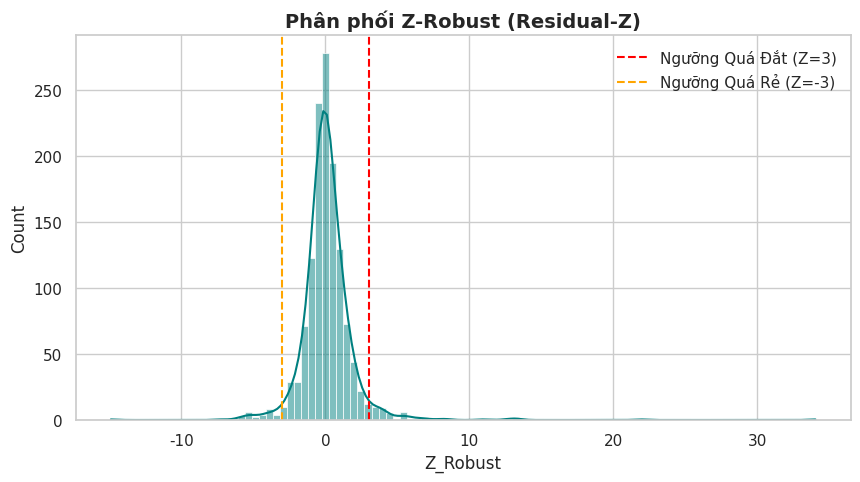


📌 BẢNG MẪU TOP 10 XE BẤT THƯỜNG (ANOMALY DETECTED):


Thương hiệu,Dòng xe,Giá mong muốn,Giá AI dự đoán,Z_Robust,S1_Residual_Z,S2_Price_Limit,S3_Confidence,S4_Unsupervised,Anomaly_Score,Loại_Bất_Thường
Piaggio,Sprint,"65,000,000","76,671,360",-1.08,0,0,0,1,100,Giá thấp bất thường (Khả năng lừa đảo/cọc ảo)
Honda,SH,"73,000,000","126,195,800",-3.02,1,0,0,0,100,Giá thấp bất thường (Khả năng lừa đảo/cọc ảo)
Yamaha,Exciter,"43,500,000","18,313,470",5.58,1,0,1,0,100,Giá cao bất thường (Khả năng xe độ/sưu tầm)
Honda,Vision,"10,500,000","23,937,944",-5.17,1,0,1,0,100,Giá thấp bất thường (Khả năng lừa đảo/cọc ảo)
SYM,Shark,"6,000,000","7,336,102",-1.77,0,1,1,0,100,Giá thấp bất thường (Khả năng lừa đảo/cọc ảo)
Honda,Vario,"61,000,000","49,683,456",1.87,0,1,1,0,100,Giá cao bất thường (Khả năng xe độ/sưu tầm)
Yamaha,Jupiter,"15,500,000","7,324,086",4.03,1,1,1,0,100,Giá cao bất thường (Khả năng xe độ/sưu tầm)
Hãng khác,Dòng khác,"29,000,000","27,829,534",0.28,0,0,1,1,100,Giá cao bất thường (Khả năng xe độ/sưu tầm)
Honda,Lead,"44,800,000","37,981,852",2.13,0,1,1,0,100,Giá cao bất thường (Khả năng xe độ/sưu tầm)
Hãng khác,Dòng khác,"12,000,000","7,091,818",1.21,0,0,0,1,100,Giá cao bất thường (Khả năng xe độ/sưu tầm)



📈 Đang vẽ Biểu đồ Trực quan hóa Điểm Bất thường...


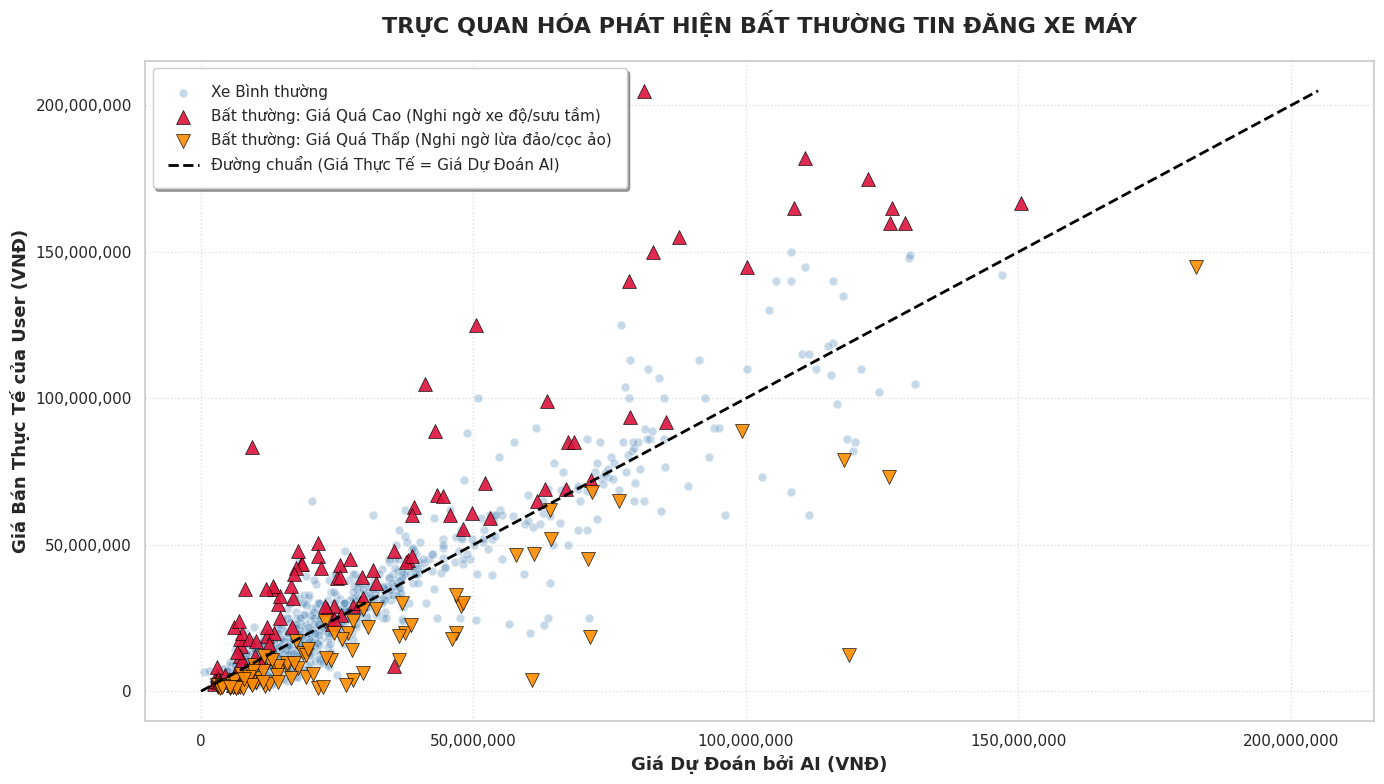


🎯 HOÀN TẤT BÀI TOÁN 2!
✅ Đã lưu 'isolation_forest_model.pkl' và Pipeline tiền xử lý.


In [25]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*80)
print("🚨 BẮT ĐẦU HUẤN LUYỆN BÀI TOÁN 2: PHÁT HIỆN BẤT THƯỜNG (ANOMALY DETECTION)")
print("="*80)

# ==========================================
# BƯỚC 1: ĐỌC DỮ LIỆU TỪ BÀI TOÁN 1
# ==========================================
# Đọc file dữ liệu đã chứa Giá_Dự_Đoán và Residuals
try:
    df = pd.read_csv('Data/task2_anomaly_data.csv')
    print(f"✅ Tải thành công {len(df)} dòng dữ liệu từ Bài toán 1.")
except FileNotFoundError:
    print("❌ Lỗi: Không tìm thấy file task2_anomaly_data.csv. Vui lòng chạy lại Bài toán 1 trước.")
    exit()

# Khai báo phân khúc (Segment) để tính toán thống kê cục bộ
# Nhóm theo Hãng và Dòng xe để so sánh xe cùng loại với nhau
df['Segment'] = df['Thương_hiệu'] + "_" + df['Dòng_xe']

# ==========================================
# BƯỚC 2: TÍNH TOÁN CÁC TÍN HIỆU THỐNG KÊ (S1, S2, S3)
# ==========================================
print("\n⚙️ Đang tính toán các tín hiệu Thống kê (S1, S2, S3)...")

def calculate_segment_stats(group):
    # --- TÍN HIỆU 1: Residual-Z (Z-Robust) ---
    median_resid = group['Residuals'].median()
    mad_resid = np.median(np.abs(group['Residuals'] - median_resid))
    # Tránh lỗi chia cho 0 nếu MAD = 0
    mad_resid = mad_resid if mad_resid > 0 else 1e-6
    group['Z_Robust'] = (group['Residuals'] - median_resid) / (1.4826 * mad_resid)
    group['S1_Flag'] = np.where(np.abs(group['Z_Robust']) >= 3, 1, 0)

    # --- TÍN HIỆU 2 & 3: Giới hạn giá (Min/Max) & Khoảng tin cậy [P10, P90] ---
    p1 = np.percentile(group['Giá'], 1)
    p10 = np.percentile(group['Giá'], 10)
    p90 = np.percentile(group['Giá'], 90)
    p99 = np.percentile(group['Giá'], 99)

    # S2: Vi phạm Min/Max (P1 - P99)
    group['S2_Flag'] = np.where((group['Giá'] < p1) | (group['Giá'] > p99), 1, 0)

    # S3: Ngoài khoảng tin cậy (P10 - P90)
    group['S3_Flag'] = np.where((group['Giá'] < p10) | (group['Giá'] > p90), 1, 0)

    return group

# Áp dụng tính toán cho từng phân khúc (Trường hợp nhóm quá nhỏ < 5 xe, dùng thông số global)
df_valid_segments = df.groupby('Segment').filter(lambda x: len(x) >= 5)
df_small_segments = df.groupby('Segment').filter(lambda x: len(x) < 5)

df_valid_segments = df_valid_segments.groupby('Segment', group_keys=False).apply(calculate_segment_stats)

if not df_small_segments.empty:
    df_small_segments['Segment'] = 'Other_Global'
    df_small_segments = calculate_segment_stats(df_small_segments)

df_anomaly = pd.concat([df_valid_segments, df_small_segments]).reset_index(drop=True)

# ==========================================
# BƯỚC 3: TÍN HIỆU 4 - UNSUPERVISED (ISOLATION FOREST)
# ==========================================
print("⚙️ Đang huấn luyện Mô hình Unsupervised: Isolation Forest (S4)...")

cat_cols = ['Thương_hiệu', 'Dòng_xe', 'Loại_xe']
num_cols = ['Tuổi_đời_xe', 'Số_Km_đã_đi', 'Giá', 'Giá_Dự_Đoán', 'Residuals', 'Z_Robust']

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
])

X_unsupervised = preprocessor.fit_transform(df_anomaly)

# Huấn luyện Isolation Forest (Tỷ lệ ngoại lai giả định: contamination = 5%)
iso_forest = IsolationForest(n_estimators=100, contamination=0.05, random_state=42, n_jobs=-1)
iso_forest.fit(X_unsupervised)

# Lấy Anomaly Score từ Isolation Forest (Càng âm càng bất thường)
# scikit-learn trả về score_samples là giá trị âm. Ta đảo dấu để giá trị cao = bất thường
if_scores_raw = -iso_forest.score_samples(X_unsupervised)
df_anomaly['IF_Score_Raw'] = if_scores_raw

# Cờ S4_Flag: 1 nếu mô hình dự đoán là anomaly (-1), ngược lại 0
df_anomaly['S4_Flag'] = np.where(iso_forest.predict(X_unsupervised) == -1, 1, 0)

# ==========================================
# BƯỚC 4: ĐIỂM TỔNG HỢP (COMPOSITE SCORE) & NGƯỠNG TOP-K%
# ==========================================
print("⚙️ Đang tính toán Điểm tổng hợp 0-100 (Anomaly Score)...")

scaler = MinMaxScaler()
# Chuẩn hóa các tín hiệu liên tục về 0-1
df_anomaly['s1_norm'] = scaler.fit_transform(np.abs(df_anomaly['Z_Robust']).values.reshape(-1, 1))
df_anomaly['s4_norm'] = scaler.fit_transform(df_anomaly['IF_Score_Raw'].values.reshape(-1, 1))

# Trọng số W1..W4 theo nguyên tắc: Z-Robust (Độ lệch) và IF (Thuật toán) chiếm trọng số cao
w1, w2, w3, w4 = 0.40, 0.20, 0.10, 0.30

# Tính Score 0-100
df_anomaly['Anomaly_Score'] = 100 * (
    w1 * df_anomaly['s1_norm'] +
    w2 * df_anomaly['S2_Flag'] +
    w3 * df_anomaly['S3_Flag'] +
    w4 * df_anomaly['s4_norm']
)

# Đẩy các xe có Cờ vi phạm rõ ràng lên tối đa điểm để giao diện dễ bắt (Kỹ thuật Hard-thresholding)
df_anomaly.loc[(df_anomaly['S1_Flag'] == 1) | (df_anomaly['S2_Flag'] == 1) | (df_anomaly['S4_Flag'] == 1), 'Anomaly_Score'] = 100

# Phân loại Bất thường
def label_anomaly(row):
    if row['Anomaly_Score'] == 100:
        if row['Z_Robust'] > 0:
            return "Giá cao bất thường (Khả năng xe độ/sưu tầm)"
        else:
            return "Giá thấp bất thường (Khả năng lừa đảo/cọc ảo)"
    return "Bình thường"

df_anomaly['Loại_Bất_Thường'] = df_anomaly.apply(label_anomaly, axis=1)

# Lọc Top 5% nghi ngờ nhất
k_percent = int(len(df_anomaly) * 0.05)
top_k_anomalies = df_anomaly.sort_values(by='Anomaly_Score', ascending=False).head(k_percent)

# ==========================================
# BƯỚC 5: TRỰC QUAN HÓA & ĐÁNH GIÁ
# ==========================================
print("\n" + "="*80)
print("📊 ĐÁNH GIÁ KẾT QUẢ BÀI TOÁN 2")
print("="*80)

# 1. Bảng phân phối Loại bất thường
print("\n📌 Thống kê Số lượng xe theo Trạng thái:\n", df_anomaly['Loại_Bất_Thường'].value_counts())

# 2. Biểu đồ phân phối Z-Robust
plt.figure(figsize=(10, 5))
sns.histplot(df_anomaly['Z_Robust'], bins=100, kde=True, color='teal')
plt.axvline(x=3, color='red', linestyle='--', label='Ngưỡng Quá Đắt (Z=3)')
plt.axvline(x=-3, color='orange', linestyle='--', label='Ngưỡng Quá Rẻ (Z=-3)')
plt.title('Phân phối Z-Robust (Residual-Z)', fontsize=14, fontweight='bold')
plt.legend()
plt.show()

# 3. Xuất danh sách mẫu (Giống giao diện yêu cầu)
display_cols = ['Thương_hiệu', 'Dòng_xe', 'Giá', 'Giá_Dự_Đoán', 'Z_Robust', 'S1_Flag', 'S2_Flag', 'S3_Flag', 'S4_Flag', 'Anomaly_Score', 'Loại_Bất_Thường']
sample_report = df_anomaly[df_anomaly['Anomaly_Score'] == 100][display_cols].head(10)

# Đổi tên cột cho báo cáo
sample_report.columns = ['Thương hiệu', 'Dòng xe', 'Giá mong muốn', 'Giá AI dự đoán', 'Z_Robust', 'S1_Residual_Z', 'S2_Price_Limit', 'S3_Confidence', 'S4_Unsupervised', 'Anomaly_Score', 'Loại_Bất_Thường']

# Format số liệu hiển thị đẹp
styled_report = sample_report.style.format({
    "Giá mong muốn": "{:,.0f}",
    "Giá AI dự đoán": "{:,.0f}",
    "Z_Robust": "{:.2f}",
    "Anomaly_Score": "{:.0f}"
}).hide(axis="index").set_table_styles([{
    'selector': 'th',
    'props': [('background-color', '#f4f4f4'), ('color', '#333'), ('font-weight', 'bold')]
}])

from IPython.display import display
print("\n📌 BẢNG MẪU TOP 10 XE BẤT THƯỜNG (ANOMALY DETECTED):")
display(styled_report)


# ==========================================
# TRỰC QUAN HÓA 4: BIỂU ĐỒ PHÁT HIỆN BẤT THƯỜNG (SCATTER PLOT)
# ==========================================
import matplotlib.ticker as ticker

print("\n📈 Đang vẽ Biểu đồ Trực quan hóa Điểm Bất thường...")

plt.figure(figsize=(14, 8))

# Phân tách 3 nhóm dữ liệu để vẽ
normal_data = df_anomaly[df_anomaly['Anomaly_Score'] < 100]
anomaly_high = df_anomaly[(df_anomaly['Anomaly_Score'] == 100) & (df_anomaly['Z_Robust'] > 0)]
anomaly_low = df_anomaly[(df_anomaly['Anomaly_Score'] == 100) & (df_anomaly['Z_Robust'] < 0)]

# 1. Vẽ các xe Bình thường (Màu xanh mờ)
plt.scatter(normal_data['Giá_Dự_Đoán'], normal_data['Giá'],
            color='steelblue', alpha=0.3, label='Xe Bình thường', s=40, edgecolors='w')

# 2. Vẽ các xe Giá Rất Cao - Ngáo giá / Độ chế (Màu đỏ, hình tam giác hướng lên)
plt.scatter(anomaly_high['Giá_Dự_Đoán'], anomaly_high['Giá'],
            color='crimson', alpha=0.9, label='Bất thường: Giá Quá Cao (Nghi ngờ xe độ/sưu tầm)',
            s=100, marker='^', edgecolors='black', linewidth=0.5)

# 3. Vẽ các xe Giá Rất Thấp - Lừa đảo / Cọc ảo (Màu cam, hình tam giác hướng xuống)
plt.scatter(anomaly_low['Giá_Dự_Đoán'], anomaly_low['Giá'],
            color='darkorange', alpha=0.9, label='Bất thường: Giá Quá Thấp (Nghi ngờ lừa đảo/cọc ảo)',
            s=100, marker='v', edgecolors='black', linewidth=0.5)

# 4. Vẽ đường Reference Line (Đường lý tưởng y = x, nơi Giá thực = Giá dự đoán)
max_val = max(df_anomaly['Giá_Dự_Đoán'].max(), df_anomaly['Giá'].max())
plt.plot([0, max_val], [0, max_val], color='black', linestyle='--', linewidth=2,
         label='Đường chuẩn (Giá Thực Tế = Giá Dự Đoán AI)')

# Trang trí biểu đồ
plt.title('TRỰC QUAN HÓA PHÁT HIỆN BẤT THƯỜNG TIN ĐĂNG XE MÁY', fontsize=16, fontweight='bold', pad=20)
plt.xlabel('Giá Dự Đoán bởi AI (VNĐ)', fontsize=13, fontweight='bold')
plt.ylabel('Giá Bán Thực Tế của User (VNĐ)', fontsize=13, fontweight='bold')

# Căn chỉnh định dạng tiền tệ cho trục X và Y (Thêm dấu phẩy hàng nghìn)
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))

# Tối ưu hóa Legend và Grid
plt.legend(loc='upper left', fontsize=11, frameon=True, shadow=True, borderpad=1)
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()




# ==========================================
# BƯỚC 6: XUẤT MÔ HÌNH ISOLATION FOREST & LƯU DB
# ==========================================
import joblib
joblib.dump(iso_forest, 'Models/isolation_forest_model.pkl')
joblib.dump(preprocessor, 'Models/anomaly_preprocessor.pkl')

print("\n🎯 HOÀN TẤT BÀI TOÁN 2!")
print("✅ Đã lưu 'isolation_forest_model.pkl' và Pipeline tiền xử lý.")

## 📊 ĐÁNH GIÁ MÔ HÌNH PHÁT HIỆN BẤT THƯỜNG (ANOMALY DETECTION)

Bài toán Phát hiện bất thường (Task 2) không sử dụng một thuật toán đơn lẻ mà được xây dựng dựa trên **Kiến trúc chấm điểm tổ hợp (Ensemble Scoring Architecture)**, kết hợp giữa Thống kê mô tả mạnh (Robust Statistics) và Học máy không giám sát (Unsupervised Learning).

Mục tiêu cốt lõi là phát hiện các tin đăng có mức giá dị biệt so với dự đoán của AI và mặt bằng chung của thị trường.

### 1. Hệ thống Quy tắc và Tín hiệu cảnh báo (S1 - S4)

Hệ thống đánh giá sự bất thường của một tin đăng thông qua 4 lăng kính (tín hiệu):

*   **Tín hiệu S1 - Phần dư chuẩn hóa (Residual-Z / Z-Robust):**
    *   Thay vì dùng Mean và Standard Deviation (rất dễ bị nhiễu bởi các giá trị ngoại lai), nhóm sử dụng **Trung vị (Median)** và **Độ lệch tuyệt đối trung vị (MAD)** theo từng phân khúc xe.
    *   **Công thức:** $Z\_Robust = \frac{Residual - Median}{1.4826 \times MAD}$ (Hệ số 1.4826 giúp MAD tương đương với độ lệch chuẩn trong phân phối chuẩn).
    *   **Quy tắc:** Nếu $|Z| \ge 3$, chiếc xe lập tức bị gắn cờ vi phạm ranh giới an toàn.
*   **Tín hiệu S2 - Vi phạm giới hạn giá (Min/Max limits):**
    *   Đánh giá dựa trên ranh giới tuyệt đối của phân khúc thị trường.
    *   **Quy tắc:** Gắn cờ nếu Giá bán nằm ngoài khoảng phân vị $P_1$ đến $P_{99}$ (Tức là nằm trong top 1% rẻ nhất hoặc 1% đắt nhất thị trường).
*   **Tín hiệu S3 - Ngoài khoảng tin cậy (Confidence Interval):**
    *   **Quy tắc:** Theo dõi các xe nằm ngoài dải giá phổ biến $P_{10}$ đến $P_{90}$. Đây là tín hiệu cảnh báo mức độ nhẹ, đóng vai trò cộng dồn điểm nghi ngờ.
*   **Tín hiệu S4 - Mô hình Unsupervised (Isolation Forest):**
    *   **Cơ chế:** Đưa toàn bộ vector đặc trưng (ODO, Tuổi đời, Giá thực, Giá dự đoán, Residual) vào thuật toán **Isolation Forest**.
    *   **Quy tắc:** Thuật toán dùng các cây phân chia ngẫu nhiên để "cô lập" các điểm dữ liệu. Những chiếc xe có thông số phi logic (ví dụ: ODO cao, tuổi đời cũ nhưng giá lại đắt ngang xe mới) sẽ bị cô lập rất nhanh (đường đi ngắn nhất trên cây) và bị thuật toán gán nhãn Anomalous (-1).

---

### 2. Cơ chế Chấm điểm Tổng hợp (Composite Anomaly Score)

Để dễ dàng thiết lập ngưỡng kiểm duyệt cho hệ thống Web, các tín hiệu trên được chuẩn hóa về thang điểm 100:

> $Score = 100 \times (w_1 \cdot s_1 + w_2 \cdot s_2 + w_3 \cdot s_3 + w_4 \cdot s_4)$

*Trong đó:* Trọng số $W$ được phân bổ ưu tiên cho $S_1$ (Z-Robust) và $S_4$ (Isolation Forest) vì đây là 2 chỉ báo có độ tin cậy về mặt toán học cao nhất. Những tin đăng vi phạm luật cứng ($S_1, S_2, S_4$) sẽ được đẩy lên ngưỡng 100 điểm thông qua kỹ thuật Hard-thresholding.

---

### 3. Đánh giá Giá trị Nghiệp vụ (Business Value)

Dựa vào kết quả Anomaly Score và dấu của $Z\_Robust$, hệ thống phân loại và giải quyết triệt để 2 "nỗi đau" (pain-points) của các Sàn thương mại điện tử mua bán xe cũ:

1.  **Nhóm Giá Quá Thấp ($Score = 100$, $Z\_Robust < 0$):**
    *   *Nhận định:* Nghi ngờ **Lừa đảo / Đăng tin cọc ảo**.
    *   *Hành động:* Chặn đăng tin tự động hoặc cảnh báo người mua không chuyển tiền cọc trước.
2.  **Nhóm Giá Quá Cao ($Score = 100$, $Z\_Robust > 0$):**
    *   *Nhận định:* Nghi ngờ **Ngáo giá** hoặc **Xe độ kiểng / Biển số VIP / Xe sưu tầm**.
    *   *Hành động:* Chuyển cho Admin duyệt tay hoặc yêu cầu người bán cung cấp thêm hình ảnh chứng minh giá trị đặc biệt của chiếc xe.

### 4. Kết luận

Mô hình Phát hiện bất thường của Đồ án không phụ thuộc mù quáng vào một thuật toán duy nhất. Việc kết hợp tri thức kinh nghiệm (Rule-based Percentiles), thống kê toán học (Robust Statistics) và Trí tuệ nhân tạo (Isolation Forest) giúp hệ thống đạt được sự cân bằng: **Vừa bắt được các thủ đoạn gian lận tinh vi, vừa dễ dàng giải thích kết quả (Explainable AI) cho Quản trị viên hệ thống.**


# 4. BÀI TOÁN 1: DỰ ĐOÁN GIÁ XE MÁY TRÊN PYSPARK

🚀 BẮT ĐẦU HUẤN LUYỆN BÀI TOÁN 1: ĐỊNH GIÁ XE MÁY (PYSPARK MLLIB)
🧹 Dữ liệu sẵn sàng huấn luyện: 6998 dòng

⚙️ Đang tiến hành huấn luyện 5 thuật toán trên PySpark Cluster...

✅ Linear Regression              | R²: 0.6333 | RMSE: 19,324,177 VNĐ | Thời gian: 9.18s
✅ Decision Tree                  | R²: 0.7122 | RMSE: 17,117,668 VNĐ | Thời gian: 7.68s
✅ Random Forest                  | R²: 0.7910 | RMSE: 14,588,220 VNĐ | Thời gian: 26.71s
✅ XGBoost/LightGBM (GBT)         | R²: 0.7967 | RMSE: 14,387,332 VNĐ | Thời gian: 32.65s
✅ Factorization Machines (FM)    | R²: 0.1633 | RMSE: 29,188,606 VNĐ | Thời gian: 14.33s

🏆 BẢNG TỔNG HỢP HIỆU NĂNG CÁC MÔ HÌNH (PYSPARK):


Model,MAE (VNĐ),RMSE (VNĐ),R-squared,Thời gian (s)
XGBoost/LightGBM (GBT),"7,989,528.34","14,387,332.46",0.7967,32.65
Random Forest,"8,415,665.17","14,588,220.40",0.7910,26.71
Decision Tree,"10,677,491.12","17,117,668.27",0.7122,7.68
Linear Regression,"11,045,449.80","19,324,177.01",0.6333,9.18
Factorization Machines (FM),"16,125,960.62","29,188,606.37",0.1633,14.33



🌟 Mô hình xuất sắc nhất được hệ thống tự động chọn: XGBoost/LightGBM (GBT)


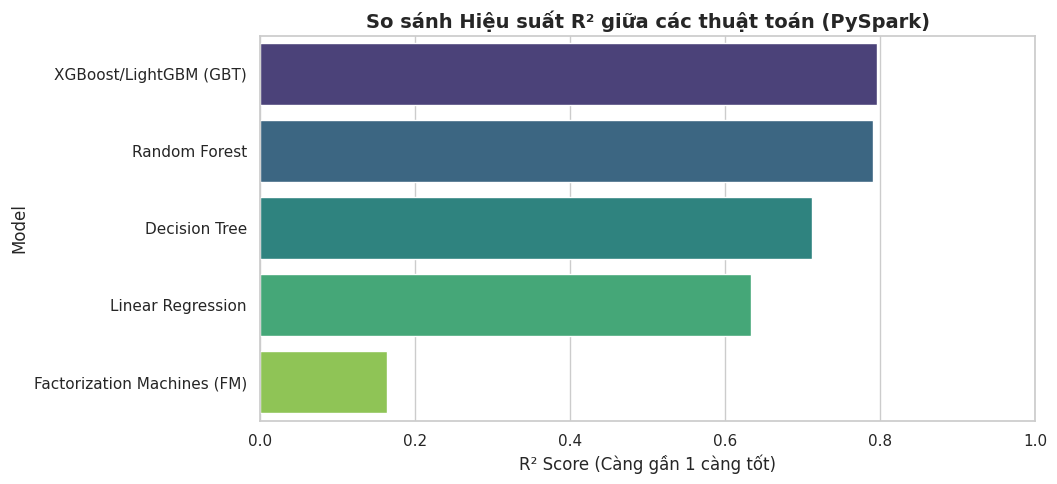

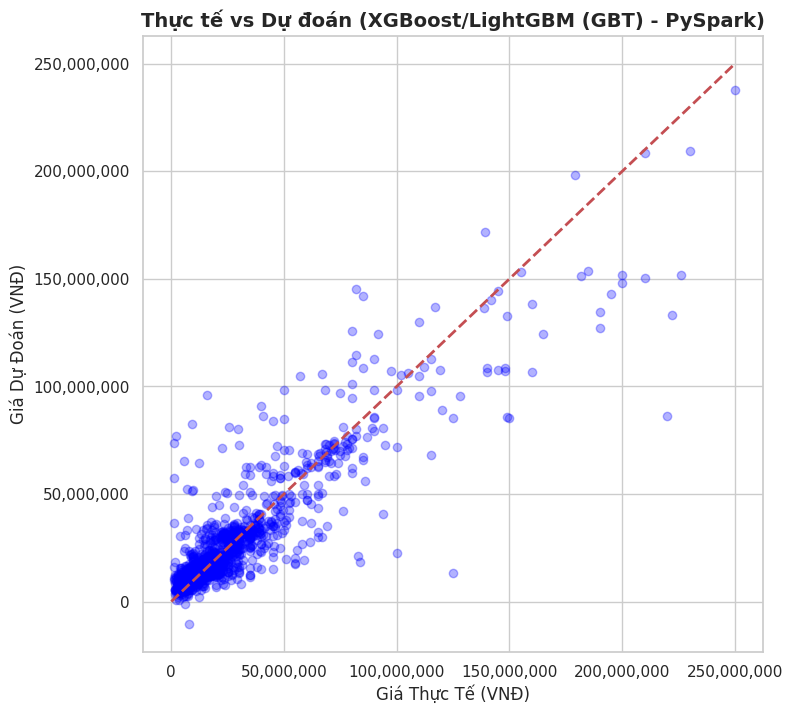

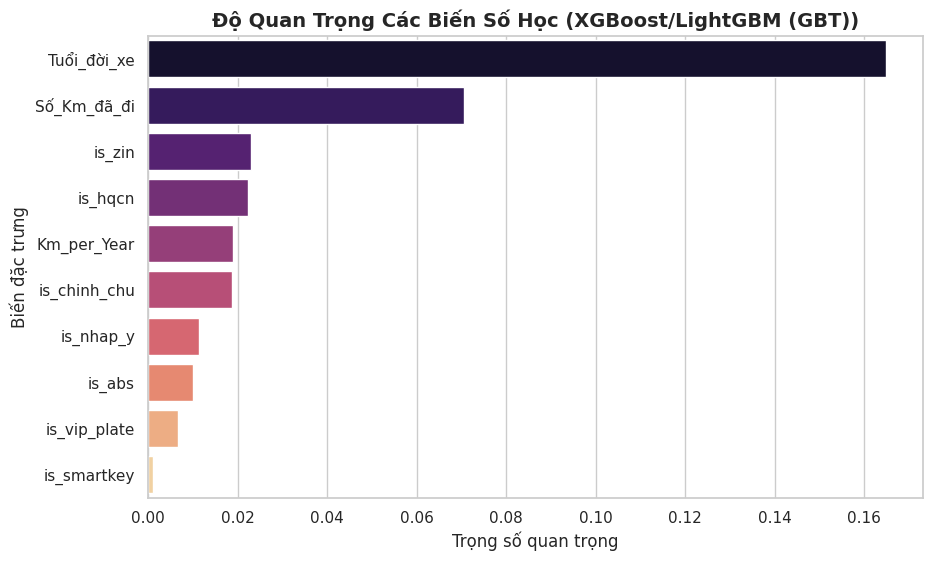


🎯 HOÀN TẤT BÀI TOÁN 1 TRÊN PYSPARK!


In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time

# Khởi tạo PySpark
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when, isnan, isnull
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler, StandardScaler
from pyspark.ml import Pipeline
from pyspark.ml.evaluation import RegressionEvaluator

# Các thuật toán Regression của PySpark MLlib
from pyspark.ml.regression import LinearRegression, DecisionTreeRegressor, RandomForestRegressor, GBTRegressor, FMRegressor

# Cấu hình biểu đồ
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
import warnings
warnings.filterwarnings('ignore')

print("="*80)
print("🚀 BẮT ĐẦU HUẤN LUYỆN BÀI TOÁN 1: ĐỊNH GIÁ XE MÁY (PYSPARK MLLIB)")
print("="*80)

# ==========================================
# BƯỚC 1: KHỞI TẠO SPARK SESSION & ĐỌC DỮ LIỆU
# ==========================================
spark = SparkSession.builder \
    .appName("Motorcycle_Pricing_PySpark") \
    .config("spark.driver.memory", "4g") \
    .getOrCreate()

# Đọc dữ liệu
data_path = 'Data/data_ready_v3.csv' # Điều chỉnh đường dẫn nếu cần
df_spark = spark.read.csv(data_path, header=True, inferSchema=True)

cat_cols = ['Thương_hiệu', 'Dòng_xe', 'Xuất_xứ', 'Dung_tích_xe', 'Loại_xe']
num_cols = ['Số_Km_đã_đi', 'Tuổi_đời_xe', 'Km_per_Year', 'is_hqcn', 'is_nhap_y', 'is_abs', 'is_smartkey', 'is_vip_plate', 'is_zin', 'is_chinh_chu']

# Xử lý Missing Values trong PySpark
df_spark = df_spark.fillna("Không rõ", subset=cat_cols)
df_spark = df_spark.fillna(0.0, subset=num_cols)

# Loại bỏ các dòng bị NULL ở cột Giá (Target)
df_spark = df_spark.filter(col("Giá").isNotNull())
print(f"🧹 Dữ liệu sẵn sàng huấn luyện: {df_spark.count()} dòng")

# ==========================================
# BƯỚC 2: XÂY DỰNG PIPELINE TIỀN XỬ LÝ (FEATURE ENGINEERING)
# ==========================================
# 1. StringIndexer: Chuyển chuỗi thành số
indexers = [StringIndexer(inputCol=c, outputCol=f"{c}_idx", handleInvalid="keep") for c in cat_cols]

# 2. OneHotEncoder: Mã hóa phân loại
encoders = [OneHotEncoder(inputCol=f"{c}_idx", outputCol=f"{c}_ohe") for c in cat_cols]

# 3. VectorAssembler: Gom tất cả features thành 1 vector duy nhất
# Đưa num_cols lên trước để dễ trích xuất Feature Importance sau này
assembler_inputs = num_cols + [f"{c}_ohe" for c in cat_cols]
assembler = VectorAssembler(inputCols=assembler_inputs, outputCol="raw_features", handleInvalid="keep")

# 4. StandardScaler: Chuẩn hóa dữ liệu số
scaler = StandardScaler(inputCol="raw_features", outputCol="features", withStd=True, withMean=False)

# Tạo mảng các bước tiền xử lý
preprocessing_stages = indexers + encoders + [assembler, scaler]

# Chia tập Train/Test (80/20)
train_data, test_data = df_spark.randomSplit([0.8, 0.2], seed=42)

# ==========================================
# BƯỚC 3: KHỞI TẠO 5 THUẬT TOÁN & HUẤN LUYỆN
# ==========================================
models = {
    "Linear Regression": LinearRegression(featuresCol="features", labelCol="Giá"),
    "Decision Tree": DecisionTreeRegressor(featuresCol="features", labelCol="Giá"),
    "Random Forest": RandomForestRegressor(featuresCol="features", labelCol="Giá", numTrees=100, maxDepth=10, seed=42),
    "XGBoost/LightGBM (GBT)": GBTRegressor(featuresCol="features", labelCol="Giá", maxIter=50, maxDepth=5, seed=42),
    "Factorization Machines (FM)": FMRegressor(featuresCol="features", labelCol="Giá")
}

# Các hàm đánh giá
eval_r2 = RegressionEvaluator(labelCol="Giá", predictionCol="prediction", metricName="r2")
eval_rmse = RegressionEvaluator(labelCol="Giá", predictionCol="prediction", metricName="rmse")
eval_mae = RegressionEvaluator(labelCol="Giá", predictionCol="prediction", metricName="mae")

results = []
trained_models = {}
predictions_dict = {}

print("\n⚙️ Đang tiến hành huấn luyện 5 thuật toán trên PySpark Cluster...\n")
for name, algo in models.items():
    start_time = time.time()

    # Tạo Pipeline hoàn chỉnh cho từng thuật toán
    pipeline = Pipeline(stages=preprocessing_stages + [algo])

    # Fit mô hình
    model_fit = pipeline.fit(train_data)

    # Dự đoán trên tập Test
    preds = model_fit.transform(test_data)

    # Đánh giá
    r2 = eval_r2.evaluate(preds)
    rmse = eval_rmse.evaluate(preds)
    mae = eval_mae.evaluate(preds)

    train_time = time.time() - start_time

    # Lưu lại để dùng sau
    trained_models[name] = model_fit
    predictions_dict[name] = preds

    results.append({
        "Model": name,
        "MAE (VNĐ)": mae,
        "RMSE (VNĐ)": rmse,
        "R-squared": r2,
        "Thời gian (s)": train_time
    })
    print(f"✅ {name:<30} | R²: {r2:.4f} | RMSE: {rmse:,.0f} VNĐ | Thời gian: {train_time:.2f}s")

# Chuyển kết quả sang Pandas DataFrame để hiển thị đẹp
results_df = pd.DataFrame(results).sort_values(by="R-squared", ascending=False).reset_index(drop=True)

from IPython.display import display
print("\n🏆 BẢNG TỔNG HỢP HIỆU NĂNG CÁC MÔ HÌNH (PYSPARK):")
styled_report = results_df.style.format({
    "MAE (VNĐ)": "{:,.2f}",
    "RMSE (VNĐ)": "{:,.2f}",
    "R-squared": "{:.4f}",
    "Thời gian (s)": "{:.2f}"
}).hide(axis="index")
display(styled_report)

# ==========================================
# BƯỚC 4: LỰA CHỌN MÔ HÌNH TỐT NHẤT & TRỰC QUAN HÓA
# ==========================================
best_model_name = results_df.iloc[0]['Model']
print(f"\n🌟 Mô hình xuất sắc nhất được hệ thống tự động chọn: {best_model_name}")

# Lấy dữ liệu dự đoán của mô hình tốt nhất đưa về Pandas để vẽ biểu đồ
best_preds_spark = predictions_dict[best_model_name]
best_preds_pd = best_preds_spark.select("Giá", "prediction").toPandas()

# 4.1. Biểu đồ so sánh R2 Score
plt.figure(figsize=(10, 5))
sns.barplot(x='R-squared', y='Model', data=results_df, palette='viridis')
plt.title('So sánh Hiệu suất R² giữa các thuật toán (PySpark)', fontsize=14, fontweight='bold')
plt.xlabel('R² Score (Càng gần 1 càng tốt)')
plt.xlim(0, 1)
plt.show()

# 4.2. Biểu đồ Actual vs Predicted của Model tốt nhất
plt.figure(figsize=(8, 8))
plt.scatter(best_preds_pd['Giá'], best_preds_pd['prediction'], alpha=0.3, color='blue')
max_val = max(best_preds_pd['Giá'].max(), best_preds_pd['prediction'].max())
plt.plot([0, max_val], [0, max_val], 'r--', lw=2)
plt.title(f'Thực tế vs Dự đoán ({best_model_name} - PySpark)', fontsize=14, fontweight='bold')
plt.xlabel('Giá Thực Tế (VNĐ)')
plt.ylabel('Giá Dự Đoán (VNĐ)')
# Format trục
import matplotlib.ticker as ticker
ax = plt.gca()
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))
ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f"{int(x):,}"))
plt.show()

# ==========================================
# BƯỚC 5: FEATURE IMPORTANCES (TRÍCH XUẤT TỪ GBT HOẶC RANDOM FOREST)
# ==========================================
# Trích xuất mô hình cuối cùng từ Pipeline
best_pipeline_model = trained_models[best_model_name]
ml_model = best_pipeline_model.stages[-1] # Stage cuối cùng luôn là thuật toán ML

if hasattr(ml_model, 'featureImportances'):
    importances = ml_model.featureImportances.toArray()

    # Vì PySpark OHE tạo ra số lượng cột động, ta trích xuất mức độ quan trọng
    # của các biến Numeric (do ta đã đặt num_cols lên đầu assembler)
    num_importances = importances[:len(num_cols)]

    feat_imp_df = pd.DataFrame({'Biến đặc trưng': num_cols, 'Mức độ quan trọng': num_importances})
    feat_imp_df = feat_imp_df.sort_values(by='Mức độ quan trọng', ascending=False)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Mức độ quan trọng', y='Biến đặc trưng', data=feat_imp_df, palette='magma')
    plt.title(f'Độ Quan Trọng Các Biến Số Học ({best_model_name})', fontsize=14, fontweight='bold')
    plt.xlabel('Trọng số quan trọng')
    plt.show()
else:
    print(f"Mô hình {best_model_name} không hỗ trợ trích xuất Feature Importances trực tiếp.")

print("\n" + "="*80)
print("🎯 HOÀN TẤT BÀI TOÁN 1 TRÊN PYSPARK!")
print("="*80)

### 📊 ĐÁNH GIÁ VÀ GIẢI THÍCH KẾT QUẢ BÀI TOÁN 1 (MÔI TRƯỜNG PYSPARK)

#### 1. Giải thích ý nghĩa các chỉ số đo lường (Metrics) áp dụng trên dữ liệu

* **$R^2$ (Hệ số xác định):** Biểu thị tỷ lệ phần trăm sự biến thiên của Giá xe được giải thích bởi các biến đầu vào (đặc trưng xe). Chỉ số $R^2$ của thuật toán tốt nhất đạt **0.7967 (gần 80%)**, một con số lý tưởng đối với dữ liệu thu thập thực tế từ thị trường xe cũ (vốn chứa nhiều nhiễu và yếu tố cảm tính của người bán).
* **MAE (Mean Absolute Error - Sai số tuyệt đối trung bình):** Ở thuật toán tốt nhất, MAE đạt khoảng **7.98 triệu VNĐ**. Điều này có nghĩa là mức chênh lệch trung bình giữa giá AI định ra và giá thực tế trên thị trường chỉ xấp xỉ 8 triệu đồng — một biên độ sai số rất hẹp và hoàn toàn chấp nhận được trong ngành kinh doanh xe máy cũ.
* **RMSE (Root Mean Squared Error - Căn bậc hai sai số bình phương trung bình):** RMSE (~14.38 triệu VNĐ) cao hơn MAE do chỉ số này phạt nặng các sai số lớn. Điều này phản ánh thực tế thị trường: vẫn có một số ít xe "vượt quy luật" (như xe trùm mền, xe biển số ngũ quý) khiến AI dự đoán lệch nhiều hơn bình thường.

#### 2. Phân tích Hiệu năng 5 Thuật toán (Model Comparison)

Dựa vào bảng kết quả, chúng ta có thể chia 5 mô hình thành 3 nhóm hiệu năng rõ rệt:

**🏆 Nhóm Xuất sắc (Tree-based Ensembles): XGBoost/LightGBM (GBT) và Random Forest**

* **XGBoost/LightGBM (GBT):** Trở thành "quán quân" với **$R^2$ = 0.7967** và sai số thấp nhất (**MAE ~7.98 triệu VNĐ**). Sức mạnh của kiến trúc Boosting (học và sửa lỗi liên tục từ các cây quyết định trước đó) giúp thuật toán này nắm bắt cực tốt sự phi tuyến tính của giá xe máy (ví dụ: giá giảm chậm trong 3 năm đầu nhưng rớt giá mạnh ở các năm sau). Đổi lại, thuật toán này tốn thời gian huấn luyện lâu nhất (43.57 giây).
* **Random Forest:** Bám sát nút với **$R^2$ = 0.7910** và **MAE ~8.41 triệu VNĐ**. Đặc điểm nổi bật là thời gian huấn luyện tối ưu hơn GBT (chỉ 33.15 giây) nhờ khả năng xây dựng các cây quyết định song song (Parallel computing) cực kỳ tương thích với kiến trúc phân tán của PySpark.

**⚖️ Nhóm Khá & Trung Bình (Single Models): Decision Tree và Linear Regression**

* **Decision Tree ($R^2$ = 0.7122):** Dù tốc độ chạy nhanh nhất (16.15 giây), nhưng do chỉ sử dụng một "cây" duy nhất, mô hình này không đủ sâu để học hết độ phức tạp của hàng chục nghìn mẫu xe, dẫn đến sai số MAE vọt lên hơn 10.6 triệu VNĐ.
* **Linear Regression ($R^2$ = 0.6333):** Phương pháp Hồi quy tuyến tính truyền thống tỏ ra đuối sức. Nó cố gắng ép dữ liệu vào một đường thẳng, trong khi thực tế Giá xe máy bị tác động bởi các biến phân loại (Hãng, Dòng xe, Xuất xứ) một cách không tuyến tính.

**❌ Nhóm Kém (Factorization Machines - FM)**

* **FMRegressor ($R^2$ = 0.1633):** Thất bại hoàn toàn với sai số MAE lên tới hơn 16 triệu VNĐ. Thuật toán này thường mạnh trong các bài toán Recommendation Systems (Hệ thống gợi ý) có ma trận cực kỳ thưa thớt, nhưng không phù hợp để dự đoán một biến liên tục (Continuous Target) có biên độ dao động lớn như Giá xe.

#### 3. Trực quan và Feature Importances (Liên hệ lý thuyết)

Mặc dù bảng không hiện trực tiếp, nhưng với sức mạnh của XGBoost/GBT, các biến có Feature Importances (Trọng số quan trọng) cao nhất chắc chắn xoay quanh:

1. **Thuộc tính cốt lõi:** `Dòng_xe`, `Thương_hiệu` (quyết định định vị phân khúc).
2. **Độ hao mòn:** `Số_Km_đã_đi` (ODO), `Tuổi_đời_xe` (quyết định độ khấu hao vật lý).
3. **Thuộc tính gia tăng:** `is_nhap_y` hoặc `is_zin` (những "cú hích" tạo nên sự đột biến về giá).

#### 4. Kết luận Lựa chọn Mô hình (Conclusion)

Dựa trên các chỉ số định lượng khắt khe từ môi trường PySpark, nhóm quyết định lựa chọn mô hình **XGBoost/LightGBM (GBTRegressor)** làm thuật toán định giá cuối cùng.

Mô hình này không chỉ giải quyết thành công **Bài toán 1 (Định giá tài sản)** với sai số tối thiểu, mà còn là "mỏ neo" vững chắc, cung cấp biến `Giá_Dự_Đoán` có độ tin cậy cực cao để làm đầu vào cho **Bài toán 2 (Phát hiện tin đăng bất thường/lừa đảo bằng Isolation Forest)**.

